In [1]:
import sys, os
sys.path.append("C:/Users/KimDongyoung/Desktop/Github/my_git/mygit/DEEPLEARNING/퍼셉트론") # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from common.optimizer import *

### 옵티마이저 비교   

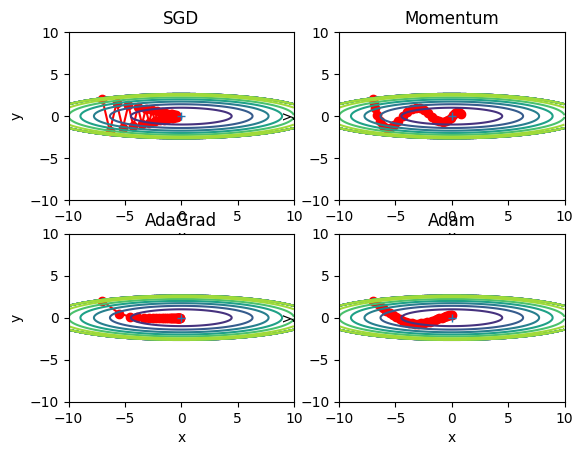

In [2]:
def f(x, y):
    return x**2 / 20.0 + y**2


def df(x, y):
    return x / 10.0, 2.0*y

init_pos = (-7.0, 2.0)
params = {}
params['x'], params['y'] = init_pos[0], init_pos[1]
grads = {}
grads['x'], grads['y'] = 0, 0


optimizers = OrderedDict()
optimizers["SGD"] = SGD(lr=0.95)
optimizers["Momentum"] = Momentum(lr=0.1)
optimizers["AdaGrad"] = AdaGrad(lr=1.5)
optimizers["Adam"] = Adam(lr=0.3)

idx = 1

for key in optimizers:
    optimizer = optimizers[key]
    x_history = []
    y_history = []
    params['x'], params['y'] = init_pos[0], init_pos[1]
    
    for i in range(30):
        x_history.append(params['x'])
        y_history.append(params['y'])
        
        grads['x'], grads['y'] = df(params['x'], params['y'])
        optimizer.update(params, grads)
    

    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)
    
    X, Y = np.meshgrid(x, y) 
    Z = f(X, Y)
    
    # 외곽선 단순화
    mask = Z > 7
    Z[mask] = 0
    
    # 그래프 그리기
    plt.subplot(2, 2, idx)
    idx += 1
    plt.plot(x_history, y_history, 'o-', color="red")
    plt.contour(X, Y, Z)
    plt.ylim(-10, 10)
    plt.xlim(-10, 10)
    plt.plot(0, 0, '+')
    #colorbar()
    #spring()
    plt.title(key)
    plt.xlabel("x")
    plt.ylabel("y")
    
plt.show()

In [3]:
import mnist as mnist
from common.util import smooth_curve
from common.multi_layer_net import MultiLayerNet
from common.optimizer import *

### mnist 데이터에 옵티마이저 성능 비교   

===========iteration:0===========
SGD:2.5079771360834995
Momentum:2.4015421241998767
AdaGrad:1.8124419818522843
Adam:2.2457613074257727
===========iteration:100===========
SGD:1.6176511628963102
Momentum:0.30427333276220386
AdaGrad:0.1168979507400857
Adam:0.19981370552567518
===========iteration:200===========
SGD:0.869976190375271
Momentum:0.327630201696468
AdaGrad:0.11482075603161397
Adam:0.18662697899470398
===========iteration:300===========
SGD:0.5956932064584288
Momentum:0.15882128241405952
AdaGrad:0.07660669458887098
Adam:0.12354524220428997
===========iteration:400===========
SGD:0.5098325063538444
Momentum:0.20392262677452988
AdaGrad:0.10927559119227903
Adam:0.1289616519794403
===========iteration:500===========
SGD:0.5227483886472921
Momentum:0.23675272790752996
AdaGrad:0.14317933593272808
Adam:0.15180610480343082
===========iteration:600===========
SGD:0.4901214345846244
Momentum:0.27370474820654567
AdaGrad:0.13664985060916532
Adam:0.1510146759123446
===========iteration:700

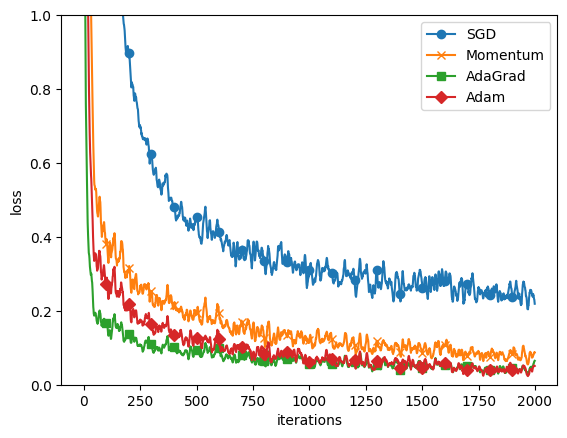

In [4]:
# 0. MNIST 데이터 읽기==========
(x_train, t_train), (x_test, t_test) = mnist.load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1. 실험용 설정==========
optimizers = {}
optimizers['SGD'] = SGD()
optimizers['Momentum'] = Momentum()
optimizers['AdaGrad'] = AdaGrad()
optimizers['Adam'] = Adam()
#optimizers['RMSprop'] = RMSprop()

networks = {}
train_loss = {}
for key in optimizers.keys():
    networks[key] = MultiLayerNet(
        input_size=784, hidden_size_list=[100, 100, 100],
        output_size=10)   # 은닉 층 3개, 출력층 1개인 신경망
    train_loss[key] = []    


# 2. 훈련 시작==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in optimizers.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizers[key].update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print( "===========" + "iteration:" + str(i) + "===========")
        for key in optimizers.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3. 그래프 그리기==========
markers = {"SGD": "o", "Momentum": "x", "AdaGrad": "s", "Adam": "D"}
x = np.arange(max_iterations)
for key in optimizers.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 1)
plt.legend()
plt.show()

### mnist 데이터를 활용하여 가중치 초기화 기법 비교   

===========iteration:0===========
std=0.01:2.3025437470042536
Xavier:2.3060407459061736
He:2.3375367736699277
===========iteration:100===========
std=0.01:2.302053279155629
Xavier:2.254937039772104
He:1.5478979895772107
===========iteration:200===========
std=0.01:2.301094841417793
Xavier:2.1215289848173646
He:0.6728734508035112
===========iteration:300===========
std=0.01:2.3029110733436173
Xavier:1.863109923902928
He:0.5060213370411233
===========iteration:400===========
std=0.01:2.3011668743070715
Xavier:1.4095406410887463
He:0.40272080892389983
===========iteration:500===========
std=0.01:2.3025180765907907
Xavier:0.9236009513697678
He:0.4000457759974526
===========iteration:600===========
std=0.01:2.299509279164872
Xavier:0.7074030638606215
He:0.37360695372327946
===========iteration:700===========
std=0.01:2.3047060558424164
Xavier:0.6482277853631222
He:0.4124525362468944
===========iteration:800===========
std=0.01:2.3020914548026017
Xavier:0.4822742452905254
He:0.29395400976840

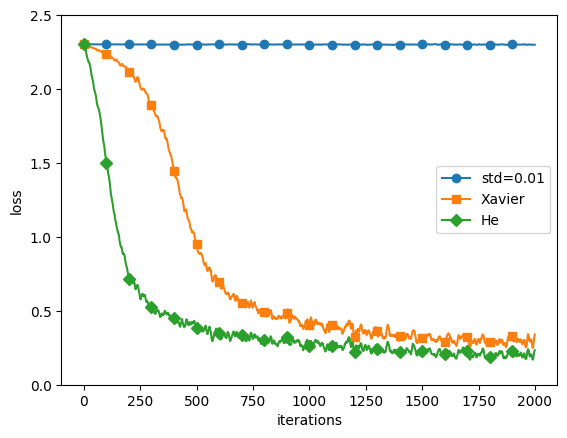

In [5]:
from common.optimizer import SGD


# 0. MNIST 데이터 읽기==========
(x_train, t_train), (x_test, t_test) = mnist.load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1. 실험용 설정==========
weight_init_types = {'std=0.01': 0.01, 'Xavier': 'sigmoid', 'He': 'relu'} # 가중치 초기화 방법
optimizer = SGD(lr=0.01)

networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []


# 2. 훈련 시작==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print("===========" + "iteration:" + str(i) + "===========")
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3. 그래프 그리기==========
markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()